In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import pingouin as pg
import numpy as np
import sklearn as sk
from scipy.stats import boxcox
from scipy.stats import rankdata


**Loading of data**


In [21]:
# Replace with our file path
df = pd.read_csv("Output_extraction/ai_grading_final.csv")

df["prompt_type"] = pd.Categorical(df["prompt_type"], 
    categories=["very_pessimistic", "pessimistic", "neutral", "confident", "very_confident"], 
    ordered=True)

# Required columns:
required_columns = [
    "answer_key_id",
    "true_mistakes",
    "prompt_type",
    "ai_estimated_mistakes"
]
df = df.dropna()
# Dependent variable: AI grading error
df["ai_error"] = df["ai_estimated_mistakes"] - df["true_mistakes"]
df["Absolute_error"] = abs(df["ai_estimated_mistakes"]-df["true_mistakes"])

df["true_mistakes"] = df["true_mistakes"].astype("category")
df["prompt_type"] = df["prompt_type"].astype("category")

**2-way Mixed ANOVA**

Assumptions: Homogeneity of variance, Independence of observations, Normally-distributed dependent variable 


ANOVA SUMMARY

Source             SS    DF1    DF2      MS       F    p_unc    p_GG_corr    np2      eps    sphericity    W_spher    p_spher
-------------  ------  -----  -----  ------  ------  -------  -----------  -----  -------  ------------  ---------  ---------
true_mistakes  71.954      7    295  10.279  16.753    0.000      nan      0.284  nan           nan        nan        nan
prompt_type    21.283      4   1180   5.321  10.031    0.000        0.000  0.033    0.724         0.000      0.534      0.000
Interaction    22.048     28   1180   0.787   1.485    0.050      nan      0.034  nan           nan        nan        nan



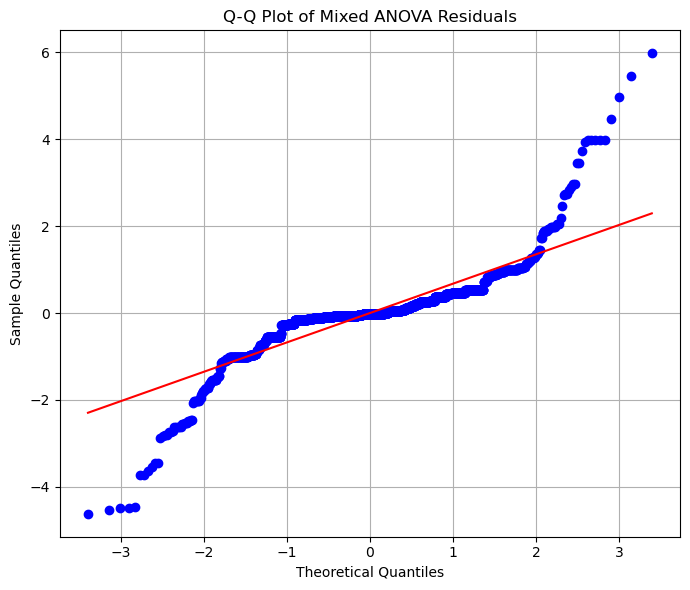

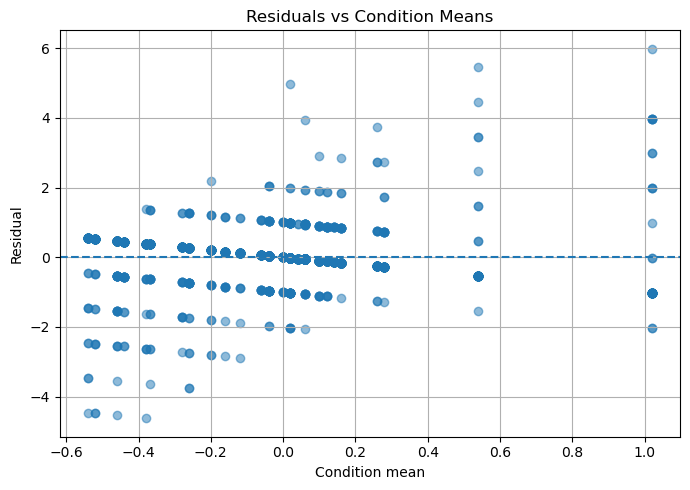

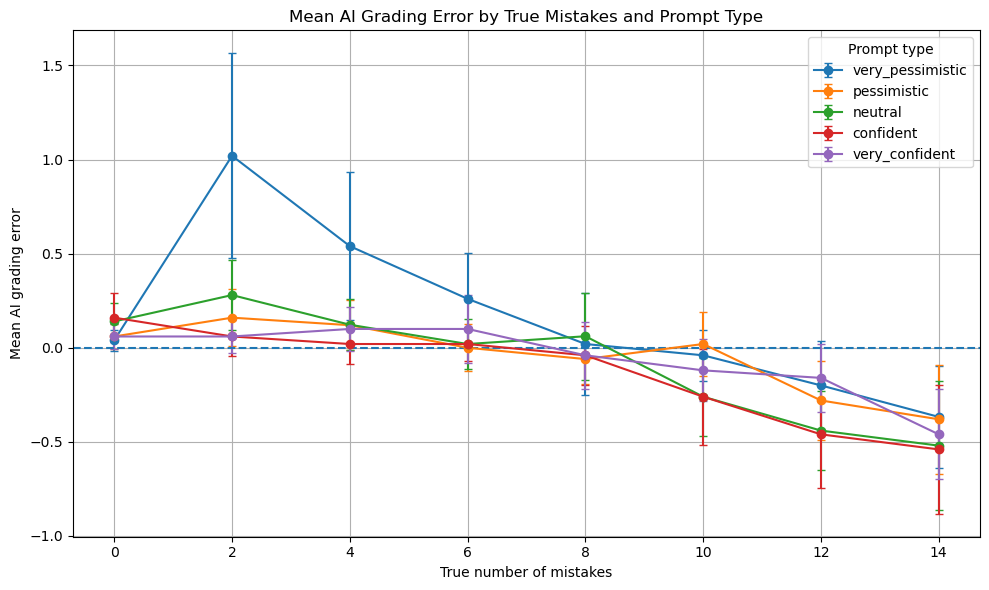

In [22]:
mixed_anova = pg.mixed_anova(
    data=df,
    dv="ai_error",
    within="prompt_type",
    between="true_mistakes",
    subject="answer_key_id"
)

pg.print_table(mixed_anova)

# 10. Q-Q plot of residual-like centered scores

df["cell_mean"] = df.groupby(
    ["true_mistakes", "prompt_type"],
    observed=False
)["ai_error"].transform("mean")

df["anova_residual"] = df["ai_error"] - df["cell_mean"]

plt.figure(figsize=(7, 6))
stats.probplot(df["anova_residual"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Mixed ANOVA Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuals vs condition means
#How far is this specific observation from the average result in the same condition? 
# One specific combination of true error level and prompt type.
#Condition means is the average value for each experimental condition.

plt.figure(figsize=(7, 5))
plt.scatter(df["cell_mean"], df["anova_residual"], alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Condition Means")
plt.xlabel("Condition mean")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot mean AI error by true mistakes and prompt

summary = (
    df.groupby(["true_mistakes", "prompt_type"], observed=False)
    .agg(
        mean_ai_error=("ai_error", "mean"),
        sd_ai_error=("ai_error", "std"),
        n=("ai_error", "count")
    )
    .reset_index()
)

summary["se_ai_error"] = summary["sd_ai_error"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["se_ai_error"]
summary["true_mistakes_numeric"] = summary["true_mistakes"].astype(int)

plt.figure(figsize=(10, 6))

for prompt in summary["prompt_type"].unique():
    subset = summary[summary["prompt_type"] == prompt]

    plt.errorbar(
        subset["true_mistakes_numeric"],
        subset["mean_ai_error"],
        yerr=subset["ci95"],
        marker="o",
        capsize=3,
        label=str(prompt)
    )
plt.axhline(0, linestyle="--")
plt.title("Mean AI Grading Error by True Mistakes and Prompt Type")
plt.xlabel("True number of mistakes")
plt.ylabel("Mean AI grading error")
plt.legend(title="Prompt type")
plt.grid(True)
plt.tight_layout()
plt.show()


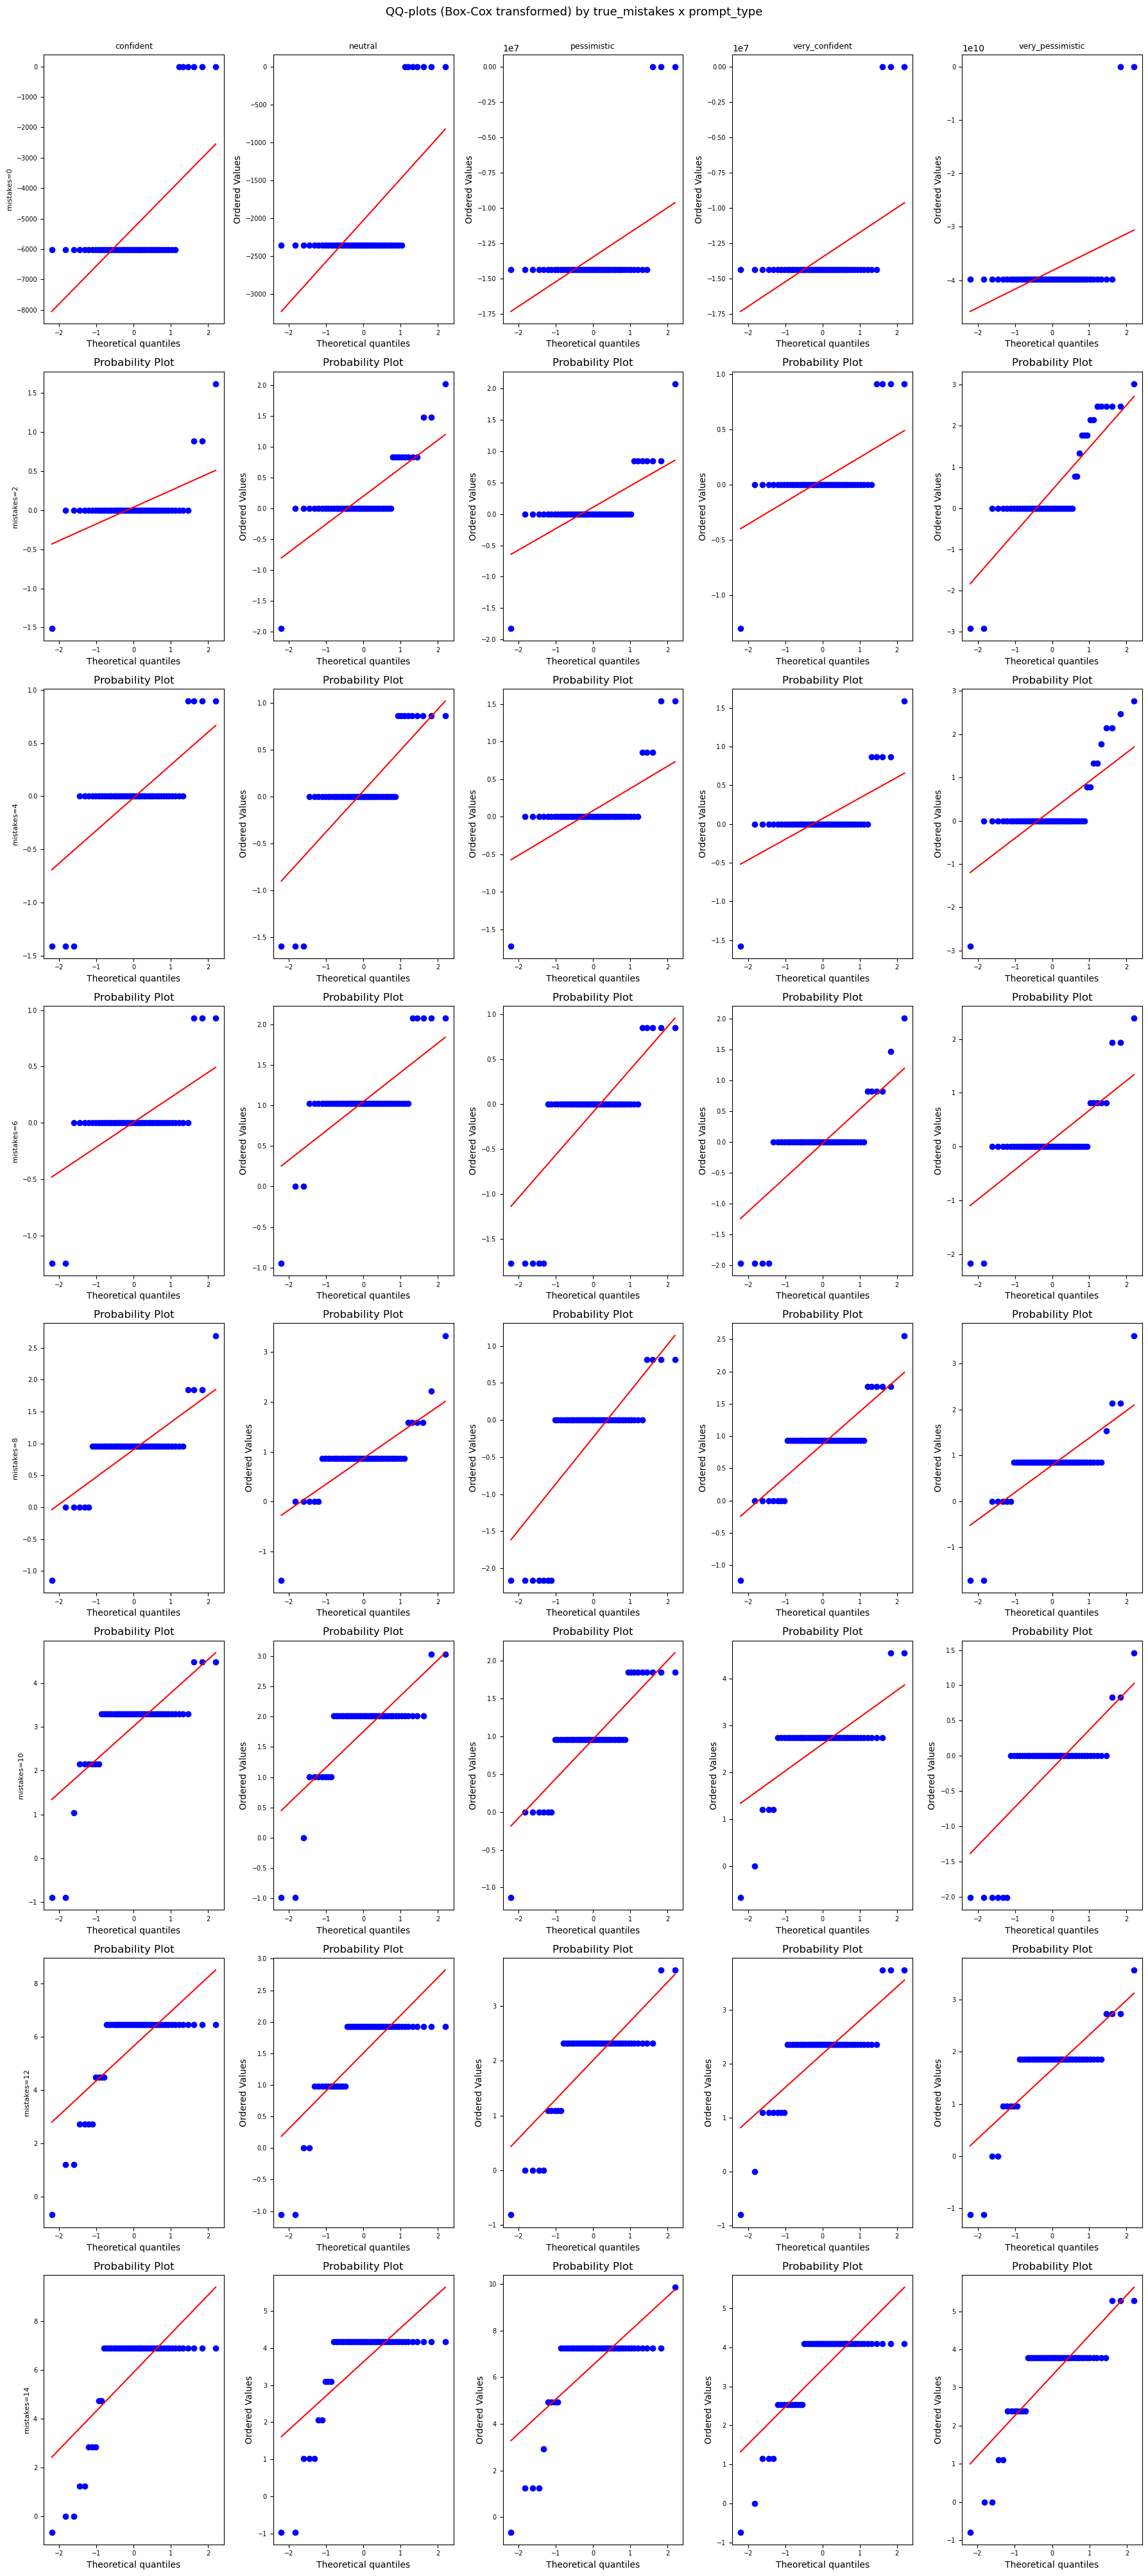

Sample of Box-Cox parameters:
(0, 'confident') {'lambda': np.float64(-0.5920417407160963), 'shift': np.float64(1e-06)}
(0, 'neutral') {'lambda': np.float64(-0.5139884957254528), 'shift': np.float64(1e-06)}
(0, 'pessimistic') {'lambda': np.float64(-1.2063722871038725), 'shift': np.float64(1e-06)}
(0, 'very_confident') {'lambda': np.float64(-1.2063722871038725), 'shift': np.float64(1e-06)}
(0, 'very_pessimistic') {'lambda': np.float64(-1.809560235155417), 'shift': np.float64(1e-06)}


In [23]:
# qq plot matrix (with optional Box-Cox)
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

matrix = df.groupby(["true_mistakes", "prompt_type"])["ai_error"].apply(np.array).unstack("prompt_type")

types = ["confident", "neutral", "pessimistic", "very_confident", "very_pessimistic"]
rows = matrix.index.tolist()  # expected 16 true_mistakes levels


def boxcox_residuals(x, eps=1e-6):
    x = np.asarray(x).ravel().astype(float)

    # Box-Cox requires strictly positive values; shift each vector if needed.
    shift = 1.0
    min_x = np.min(x)
    if min_x <= 0:
        shift = -min_x + eps

    x_pos = x + shift

    # Box-Cox also needs non-constant data.
    if np.allclose(x_pos, x_pos[0]):
        return None, np.nan, shift

    x_bc, lam = stats.boxcox(x_pos)
    return x_bc, lam, shift


fig, axes = plt.subplots(len(rows), len(types), figsize=(18, 40), squeeze=False)
lambda_table = {}

for r, tm in enumerate(rows):
    for c, prompt in enumerate(types):
        ax = axes[r, c]

        if prompt not in matrix.columns:
            ax.set_visible(False)
            continue

        res_raw = matrix.loc[tm, prompt]
        if not isinstance(res_raw, (np.ndarray, list, tuple)):
            ax.set_visible(False)
            continue

        res = np.asarray(res_raw).ravel()
        if res.size < 3:
            ax.set_visible(False)
            continue

        res_bc, lam, shift = boxcox_residuals(res)
        if res_bc is None:
            ax.set_visible(False)
            continue

        stats.probplot(res_bc, dist="norm", plot=ax)
        lambda_table[(tm, prompt)] = {"lambda": lam, "shift": shift}

        if r == 0:
            ax.set_title(prompt, fontsize=9)
        if c == 0:
            ax.set_ylabel(f"mistakes={tm}", fontsize=8)
        ax.tick_params(labelsize=7)

fig.suptitle("QQ-plots (Box-Cox transformed) by true_mistakes x prompt_type", y=1.002, fontsize=13)
plt.tight_layout()
plt.show()

print("Sample of Box-Cox parameters:")
for k, v in list(lambda_table.items())[:5]:
    print(k, v)

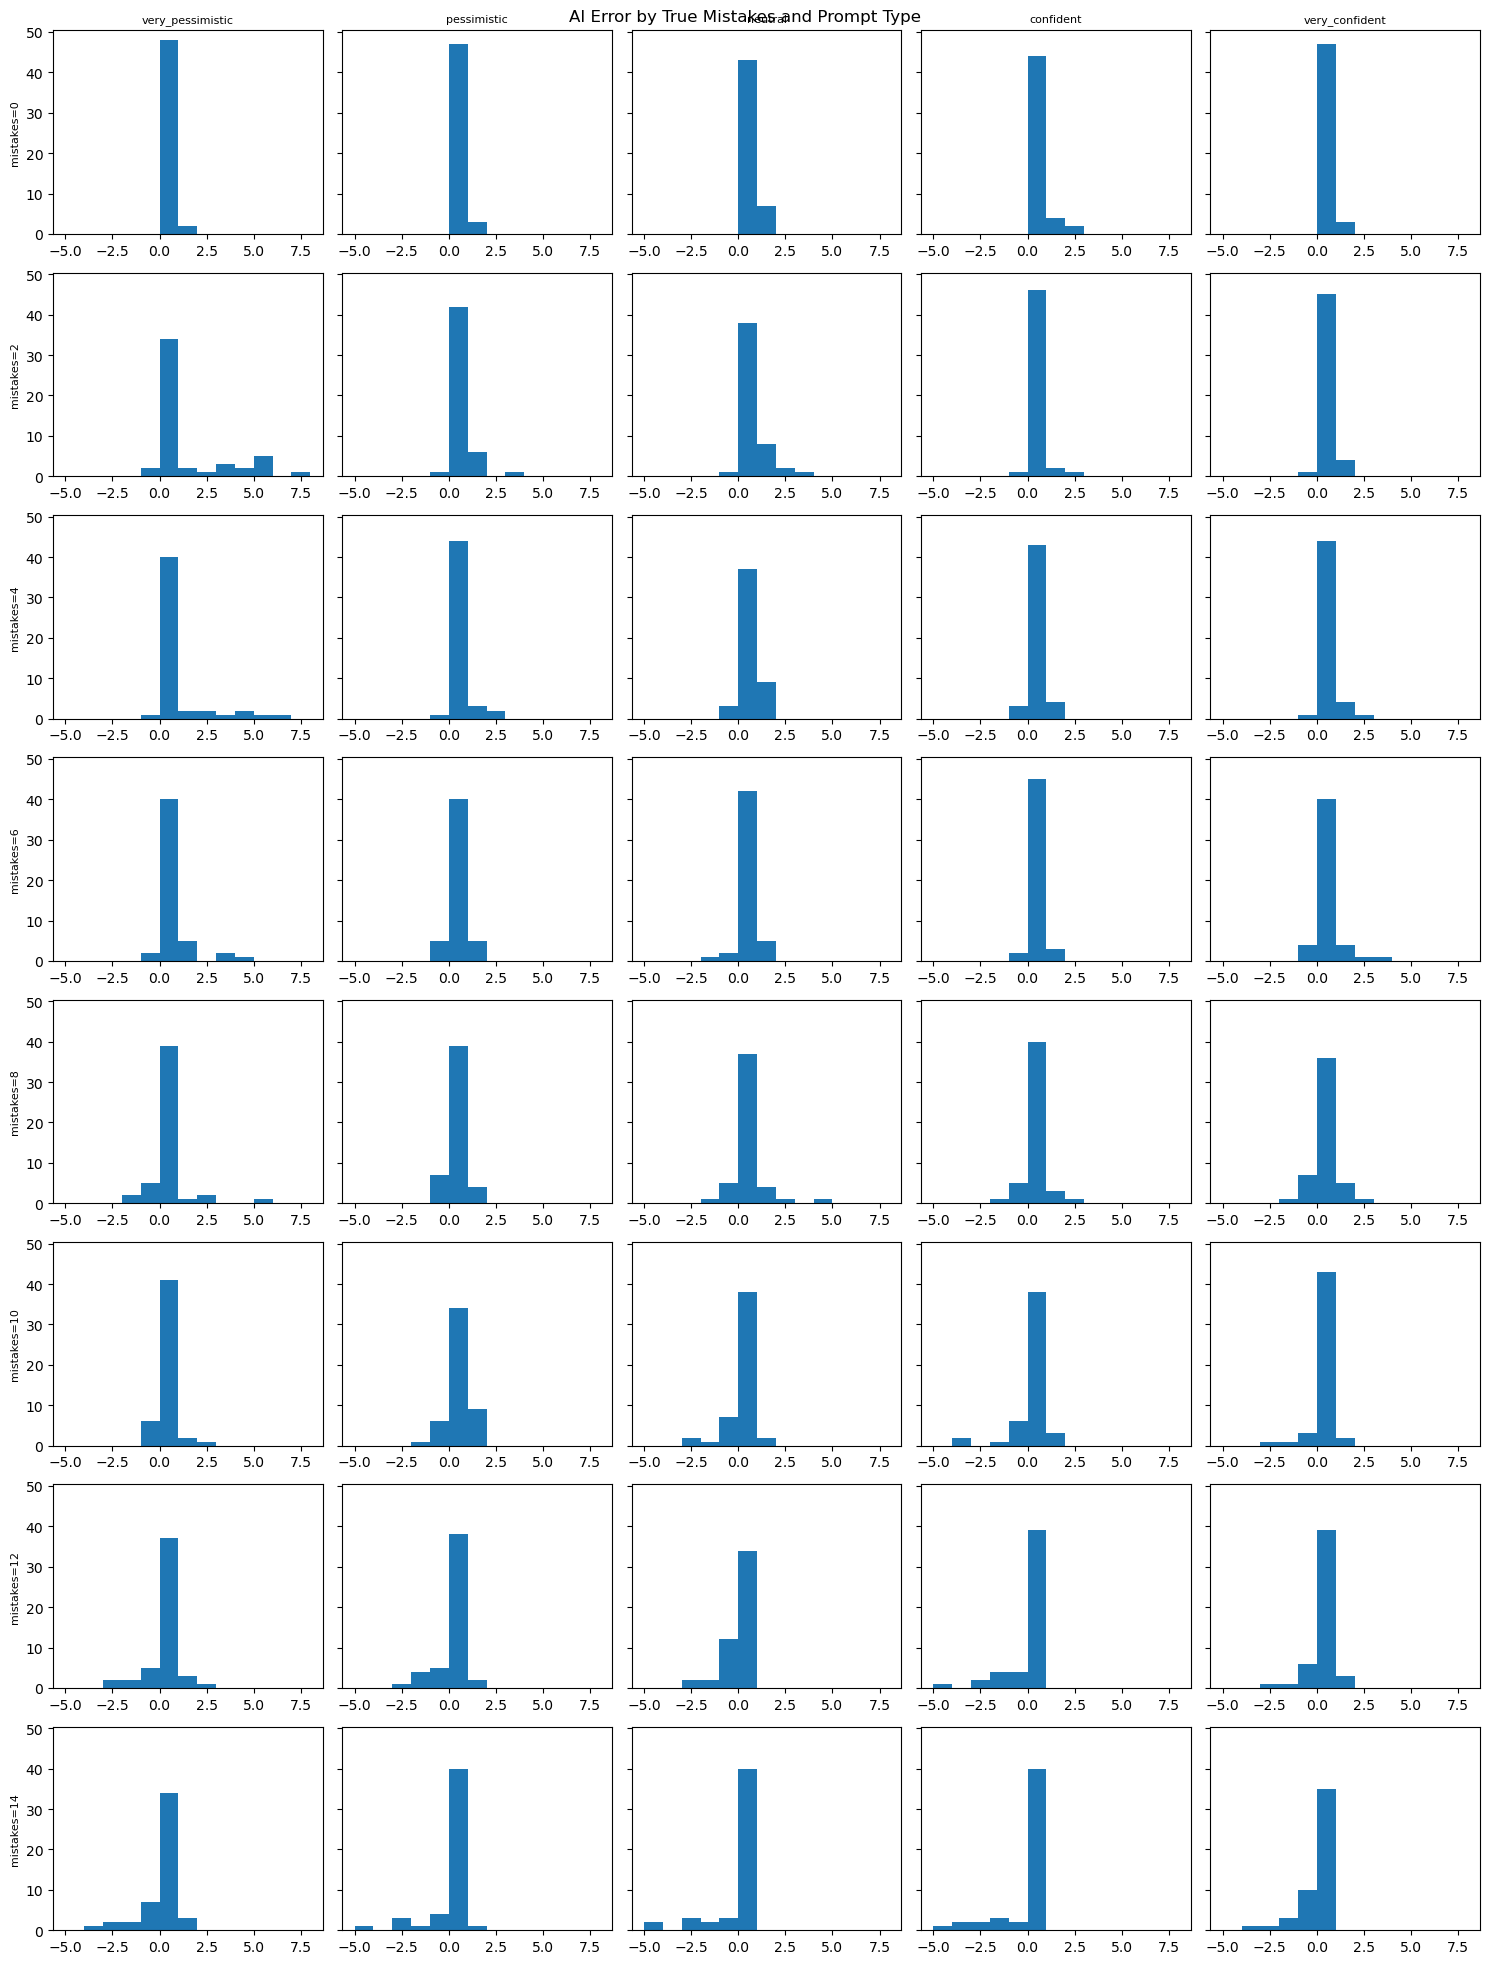

In [24]:
all_data = [x for sublist in matrix.values.flatten() for x in sublist]
global_bins = np.arange(min(all_data), max(all_data) + 2)

fig, axes = plt.subplots(len(matrix.index), len(matrix.columns), figsize=(15, 20), sharey=True)

for i, true_mistakes in enumerate(matrix.index):
    for j, prompt_type in enumerate(matrix.columns):
        ax = axes[i, j]
        data = matrix.loc[true_mistakes, prompt_type]
        ax.hist(data, bins=global_bins)
        if i == 0:
            ax.set_title(prompt_type, fontsize=8)
        if j == 0:
            ax.set_ylabel(f"mistakes={true_mistakes}", fontsize=8)

plt.suptitle("AI Error by True Mistakes and Prompt Type")
plt.tight_layout()
plt.show()

**ABSOLUTE ERROR VERSION**


ANOVA SUMMARY

Source             SS    DF1    DF2     MS      F    p_unc    p_GG_corr    np2      eps    sphericity    W_spher    p_spher
-------------  ------  -----  -----  -----  -----  -------  -----------  -----  -------  ------------  ---------  ---------
true_mistakes   7.756      7    295  1.108  2.127    0.041      nan      0.048  nan           nan        nan        nan
prompt_type    12.640      4   1180  3.160  6.346    0.000        0.000  0.021    0.720         0.000      0.528      0.000
Interaction    25.120     28   1180  0.897  1.802    0.007      nan      0.041  nan           nan        nan        nan



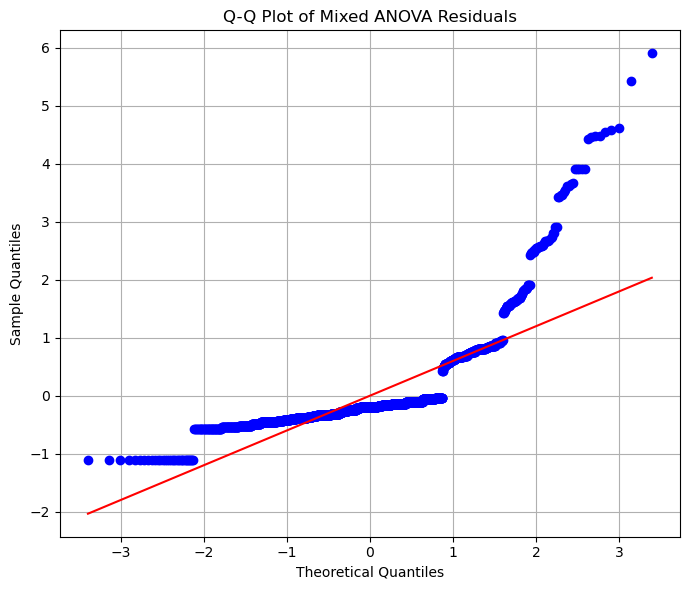

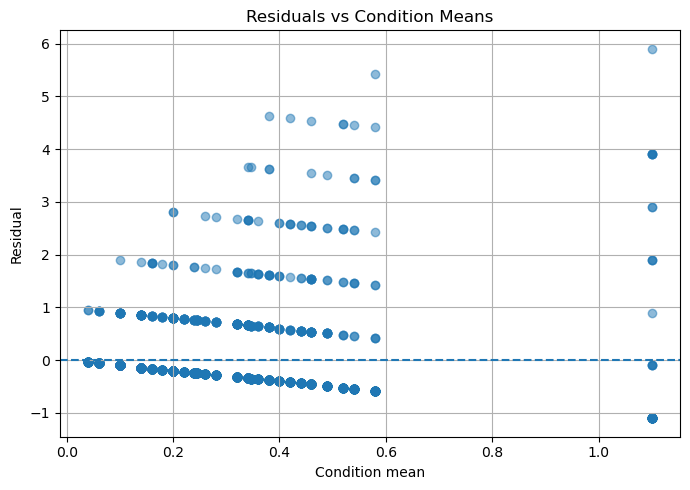

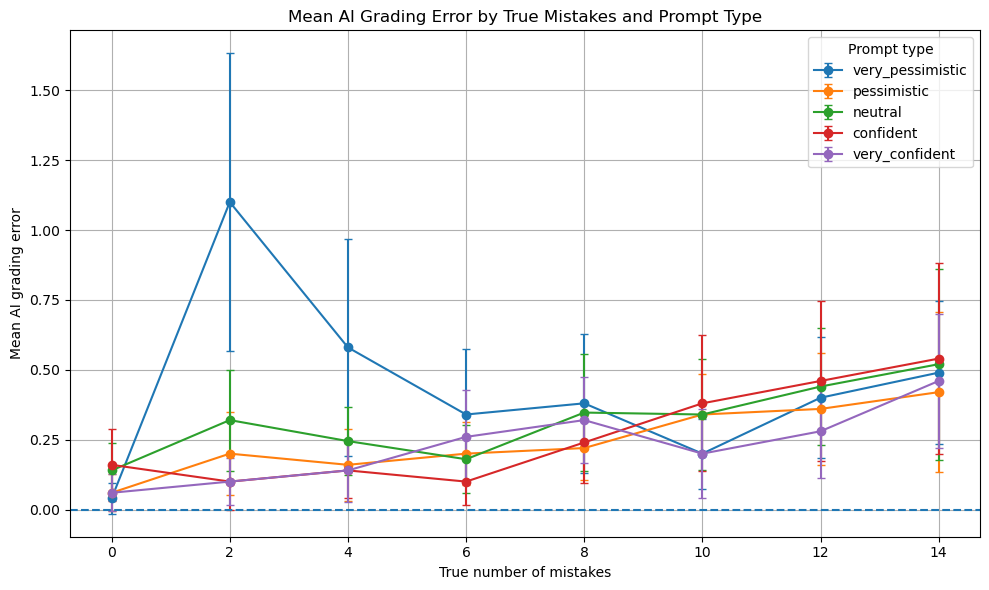

In [25]:
mixed_anova = pg.mixed_anova(
    data=df,
    dv="Absolute_error",
    within="prompt_type",
    between="true_mistakes",
    subject="answer_key_id"
)

pg.print_table(mixed_anova)

# 10. Q-Q plot of residual-like centered scores

df["cell_mean"] = df.groupby(
    ["true_mistakes", "prompt_type"],
    observed=False
)["Absolute_error"].transform("mean")

df["anova_residual"] = df["Absolute_error"] - df["cell_mean"]

plt.figure(figsize=(7, 6))
stats.probplot(df["anova_residual"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Mixed ANOVA Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuals vs condition means

plt.figure(figsize=(7, 5))
plt.scatter(df["cell_mean"], df["anova_residual"], alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Condition Means")
plt.xlabel("Condition mean")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot mean AI error by true mistakes and prompt

summary = (
    df.groupby(["true_mistakes", "prompt_type"], observed=False)
    .agg(
        mean_ai_error=("Absolute_error", "mean"),
        sd_ai_error=("Absolute_error", "std"),
        n=("Absolute_error", "count")
    )
    .reset_index()
)

summary["se_ai_error"] = summary["sd_ai_error"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["se_ai_error"]
summary["true_mistakes_numeric"] = summary["true_mistakes"].astype(int)

plt.figure(figsize=(10, 6))

for prompt in summary["prompt_type"].unique():
    subset = summary[summary["prompt_type"] == prompt]

    plt.errorbar(
        subset["true_mistakes_numeric"],
        subset["mean_ai_error"],
        yerr=subset["ci95"],
        marker="o",
        capsize=3,
        label=str(prompt)
    )

plt.axhline(0, linestyle="--")
plt.title("Mean AI Grading Error by True Mistakes and Prompt Type")
plt.xlabel("True number of mistakes")
plt.ylabel("Mean AI grading error")
plt.legend(title="Prompt type")
plt.grid(True)
plt.tight_layout()
plt.show()

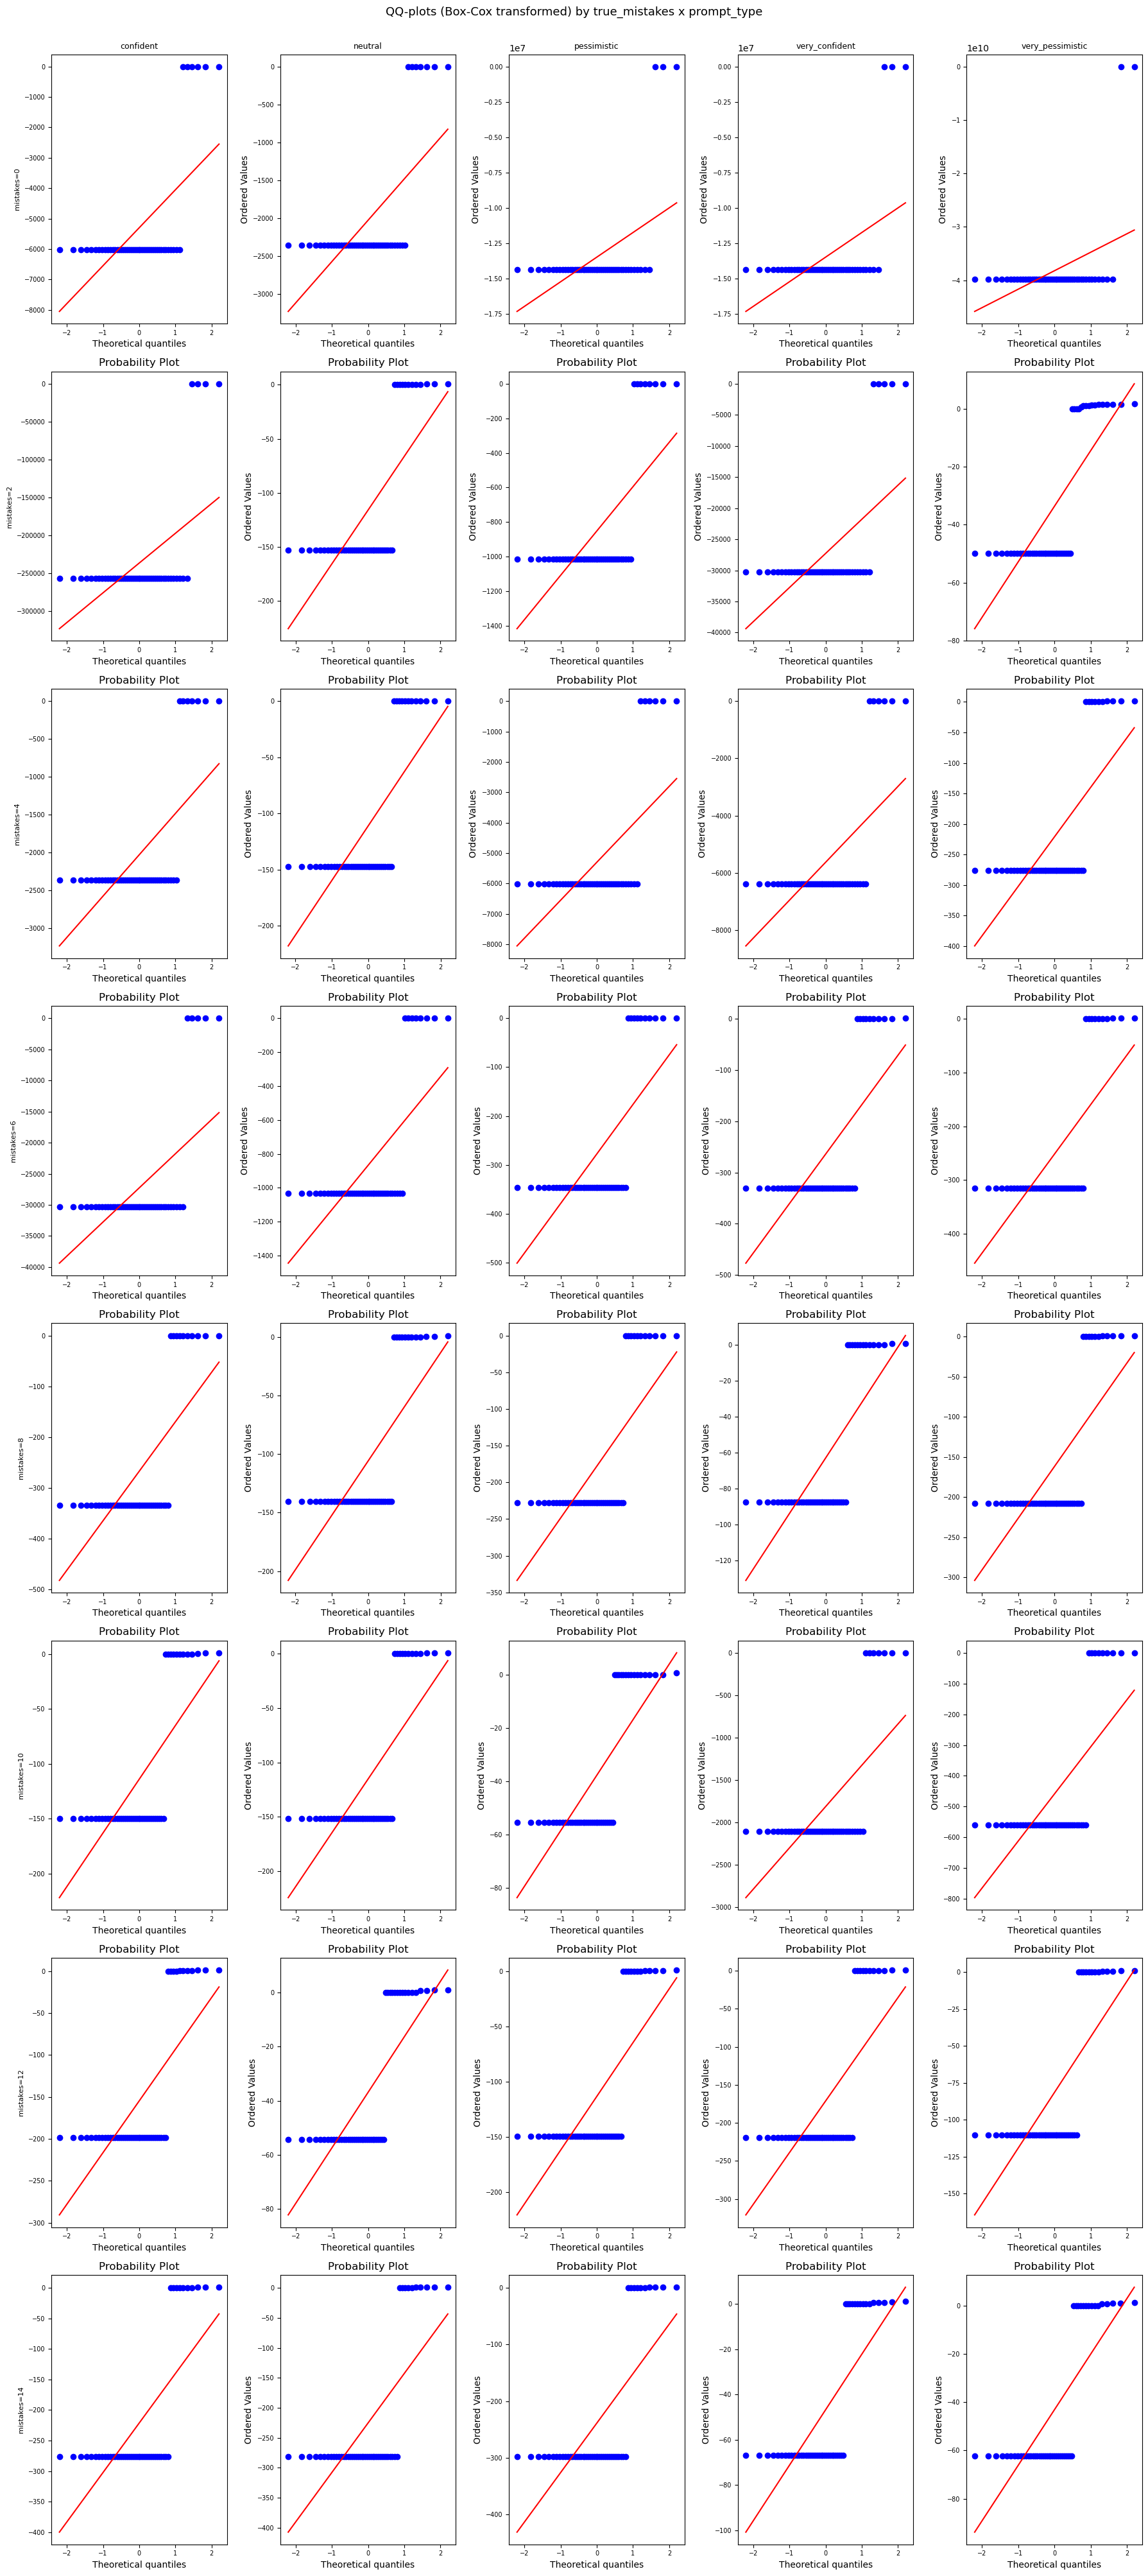

Sample of Box-Cox parameters:
(0, 'confident') {'lambda': np.float64(-0.5920417407160963), 'shift': np.float64(1e-06)}
(0, 'neutral') {'lambda': np.float64(-0.5139884957254528), 'shift': np.float64(1e-06)}
(0, 'pessimistic') {'lambda': np.float64(-1.2063722871038725), 'shift': np.float64(1e-06)}
(0, 'very_confident') {'lambda': np.float64(-1.2063722871038725), 'shift': np.float64(1e-06)}
(0, 'very_pessimistic') {'lambda': np.float64(-1.809560235155417), 'shift': np.float64(1e-06)}


In [26]:
# qq plot matrix (with optional Box-Cox)
matrix = df.groupby(["true_mistakes", "prompt_type"])["Absolute_error"].apply(np.array).unstack("prompt_type")

types = ["confident", "neutral", "pessimistic", "very_confident", "very_pessimistic"]
rows = matrix.index.tolist()  # expected 16 true_mistakes levels


def boxcox_residuals(x, eps=1e-6):
    x = np.asarray(x).ravel().astype(float)

    # Box-Cox requires strictly positive values; shift each vector if needed.
    shift = 1.0
    min_x = np.min(x)
    if min_x <= 0:
        shift = -min_x + eps

    x_pos = x + shift

    # Box-Cox also needs non-constant data.
    if np.allclose(x_pos, x_pos[0]):
        return None, np.nan, shift

    x_bc, lam = stats.boxcox(x_pos)
    return x_bc, lam, shift


fig, axes = plt.subplots(len(rows), len(types), figsize=(18, 40), squeeze=False)
lambda_table = {}

for r, tm in enumerate(rows):
    for c, prompt in enumerate(types):
        ax = axes[r, c]

        if prompt not in matrix.columns:
            ax.set_visible(False)
            continue

        res_raw = matrix.loc[tm, prompt]
        if not isinstance(res_raw, (np.ndarray, list, tuple)):
            ax.set_visible(False)
            continue

        res = np.asarray(res_raw).ravel()
        if res.size < 3:
            ax.set_visible(False)
            continue

        res_bc, lam, shift = boxcox_residuals(res)
        if res_bc is None:
            ax.set_visible(False)
            continue

        stats.probplot(res_bc, dist="norm", plot=ax)
        lambda_table[(tm, prompt)] = {"lambda": lam, "shift": shift}

        if r == 0:
            ax.set_title(prompt, fontsize=9)
        if c == 0:
            ax.set_ylabel(f"mistakes={tm}", fontsize=8)
        ax.tick_params(labelsize=7)

fig.suptitle("QQ-plots (Box-Cox transformed) by true_mistakes x prompt_type", y=1.002, fontsize=13)
plt.tight_layout()
plt.show()

print("Sample of Box-Cox parameters:")
for k, v in list(lambda_table.items())[:5]:
    print(k, v)

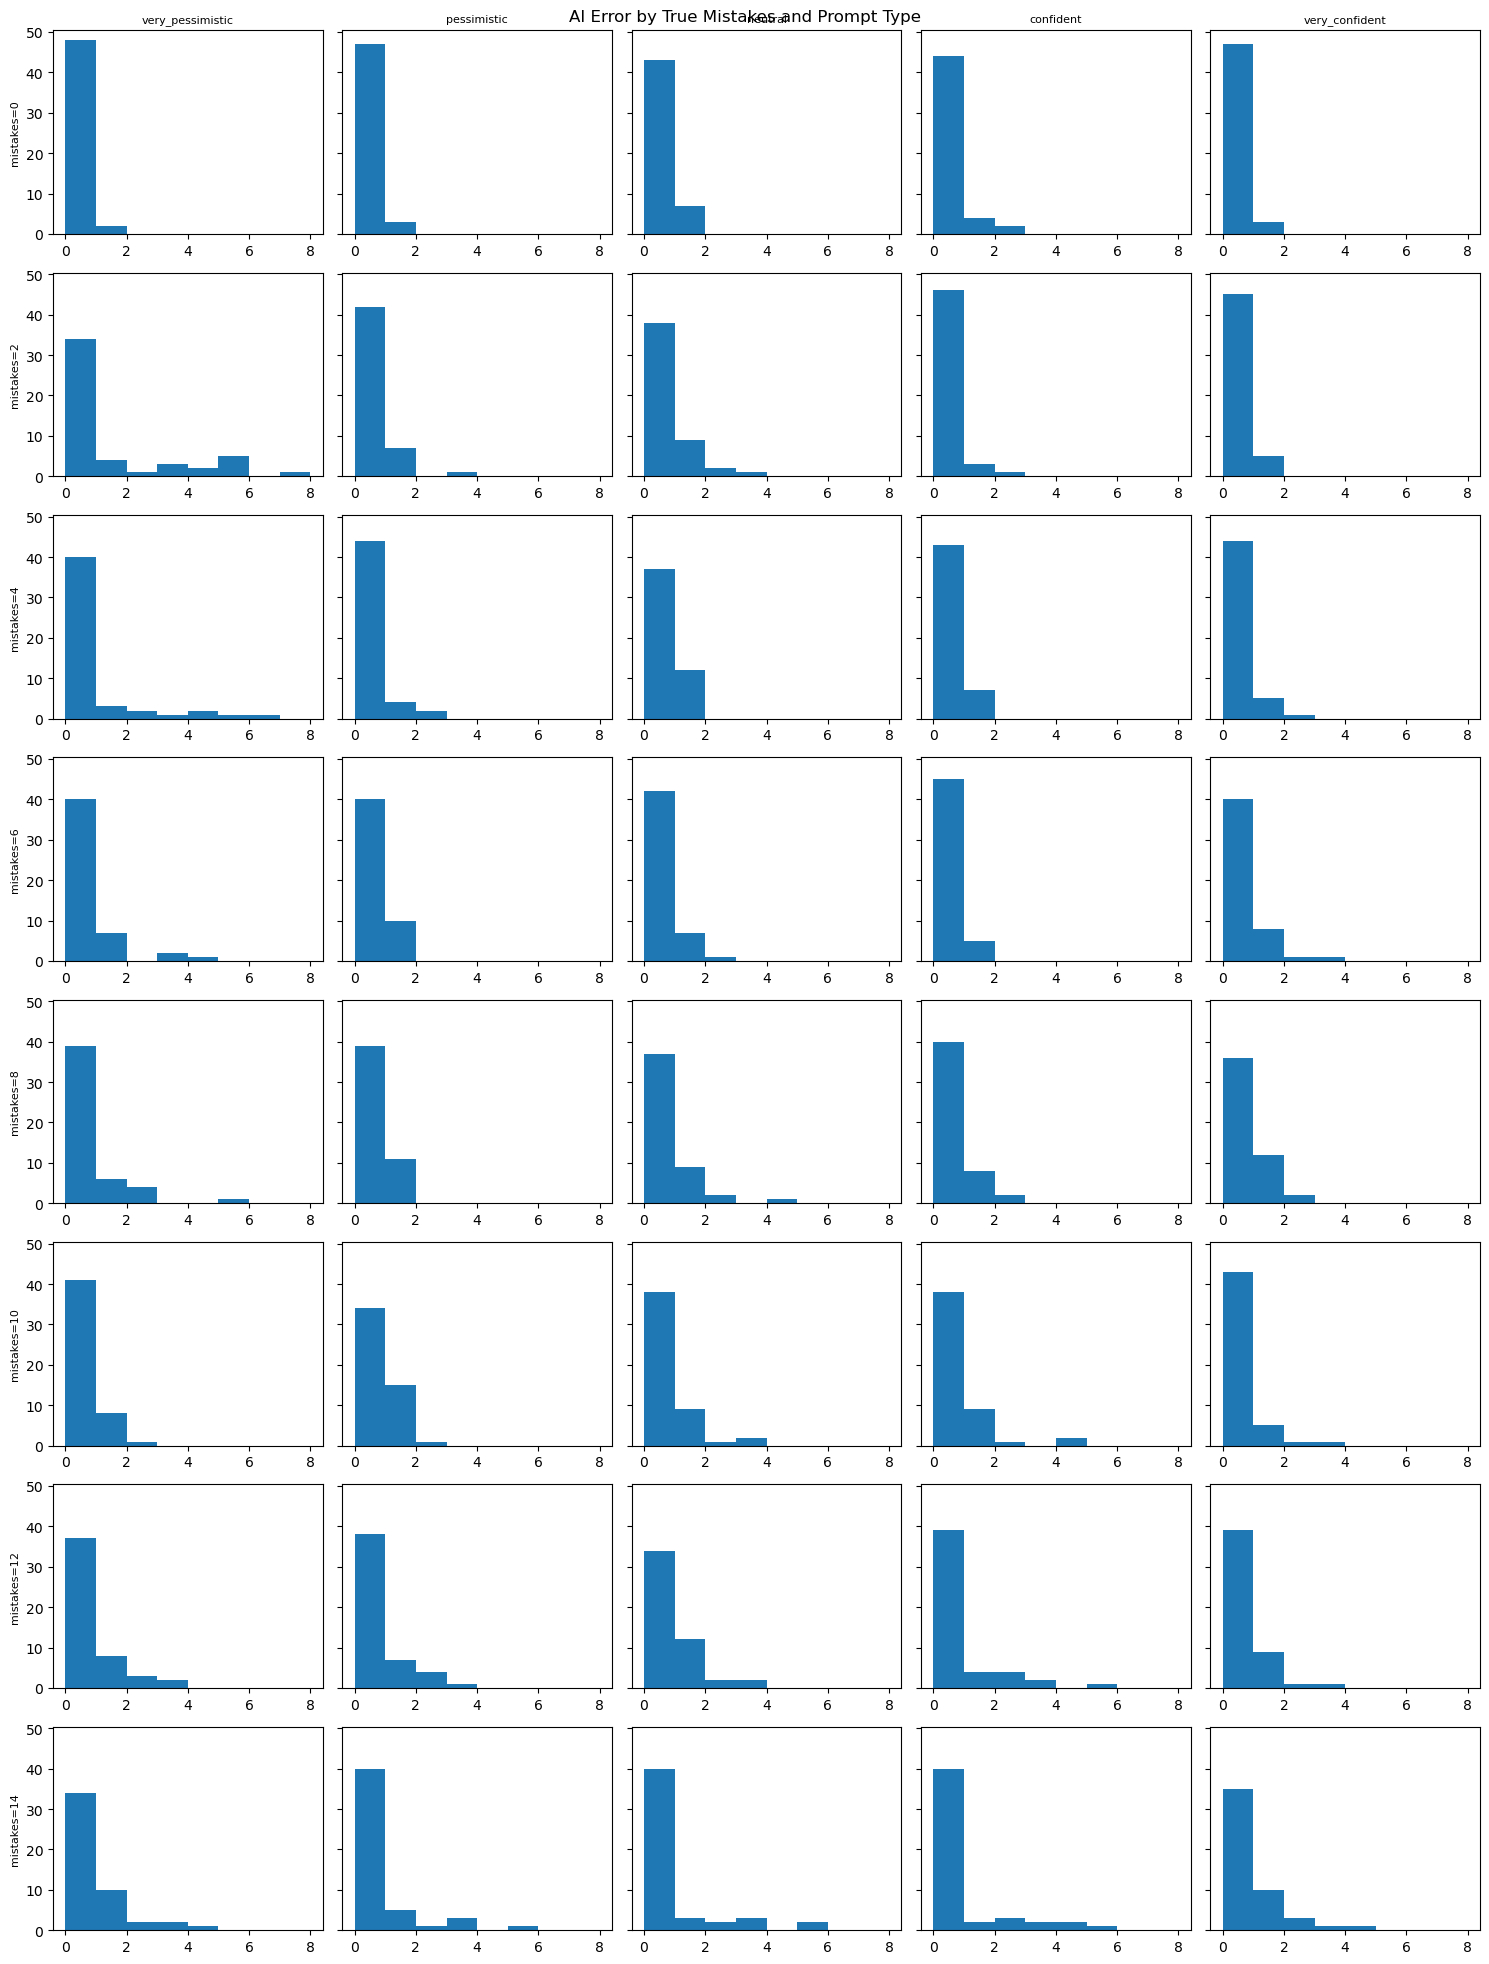

In [27]:
all_data = [x for sublist in matrix.values.flatten() for x in sublist]
global_bins = np.arange(min(all_data), max(all_data) + 2)

fig, axes = plt.subplots(len(matrix.index), len(matrix.columns), figsize=(15, 20), sharey=True)

for i, true_mistakes in enumerate(matrix.index):
    for j, prompt_type in enumerate(matrix.columns):
        ax = axes[i, j]
        data = matrix.loc[true_mistakes, prompt_type]
        ax.hist(data, bins=global_bins)
        if i == 0:
            ax.set_title(prompt_type, fontsize=8)
        if j == 0:
            ax.set_ylabel(f"mistakes={true_mistakes}", fontsize=8)

plt.suptitle("AI Error by True Mistakes and Prompt Type")
plt.tight_layout()
plt.show()

Ikke normal fordelt så vi bruger ART

In [28]:
def aligned_rank_transform(df, dv, within, between, subject):
    df = df.copy()
    df[within]  = df[within].astype(str)
    df[between] = df[between].astype(str)

    grand_mean = df[dv].mean()

    mean_A   = df.groupby(within,  observed=True)[dv].transform("mean")  # Ā_i
    mean_B   = df.groupby(between, observed=True)[dv].transform("mean")  # B̄_j
    mean_AB  = df.groupby([within, between], observed=True)[dv].transform("mean")  # ĀB̄_ij

    # Trin 1: Beregn residualer 
    cell_mean = df.groupby([subject, within, between], observed=True)[dv].transform("mean")
    # finder alle forskellige kombier af key_id, prompt_type og true mistakes, finder gennemsnittet af ai error for de forskellige kombier, sætter gennemsnittet ind på de forskellige kombier.  
    residual  = df[dv] - cell_mean


    # Trin 2 beregn effekt
    # Effekt A (within / prompt_type):      Ā_i - µ
    effect_A   = mean_A - grand_mean

    # Effekt B (between / true_mistakes):   B̄_j - µ
    effect_B   = mean_B - grand_mean

    # Effekt A*B (interaktion):             ĀB̄_ij - Ā_i - B̄_j + µ
    effect_AB  = mean_AB - mean_A - mean_B + grand_mean


    #Trin 3: Aligned response Y' = residual + estimeret effekt 
    df["Y_prime_A"]  = residual + effect_A
    df["Y_prime_B"]  = residual + effect_B
    df["Y_prime_AB"] = residual + effect_AB

    #Trin 4: Rang Y' → Y''
    df["Y_ranked_A"]  = rankdata(df["Y_prime_A"])
    df["Y_ranked_B"]  = rankdata(df["Y_prime_B"])
    df["Y_ranked_AB"] = rankdata(df["Y_prime_AB"])

    # Ensuring correctness
    print("Verificering — aligned kolonner skal summe til ~0:")
    print(f"  Y'_A  sum: {df['Y_prime_A'].sum():.6f}")
    print(f"  Y'_B  sum: {df['Y_prime_B'].sum():.6f}")
    print(f"  Y'_AB sum: {df['Y_prime_AB'].sum():.6f}")

    return df


Først for ai-erro, altså signed error

Verificering — aligned kolonner skal summe til ~0:
  Y'_A  sum: -0.000000
  Y'_B  sum: 0.000000
  Y'_AB sum: -0.000000

ANOVA SUMMARY

Source                  SS    DF1    DF2            MS          F    p_unc    p_GG_corr    np2    eps  sphericity      W_spher    p_spher
-----------  -------------  -----  -----  ------------  ---------  -------  -----------  -----  -----  ------------  ---------  ---------
prompt_type  327542915.154      4   1180  81885728.789  10406.839    0.000        0.000  0.972  0.483  False             0.106      0.000


ANOVA SUMMARY

Source                    SS    DF1    DF2            MS         F    p_unc    p_GG_corr    np2    eps    sphericity    W_spher    p_spher
-------------  -------------  -----  -----  ------------  --------  -------  -----------  -----  -----  ------------  ---------  ---------
true_mistakes  414546235.687      7    295  59220890.812  1851.358    0.000          nan  0.978    nan           nan        nan        nan


ANOVA SUMMARY



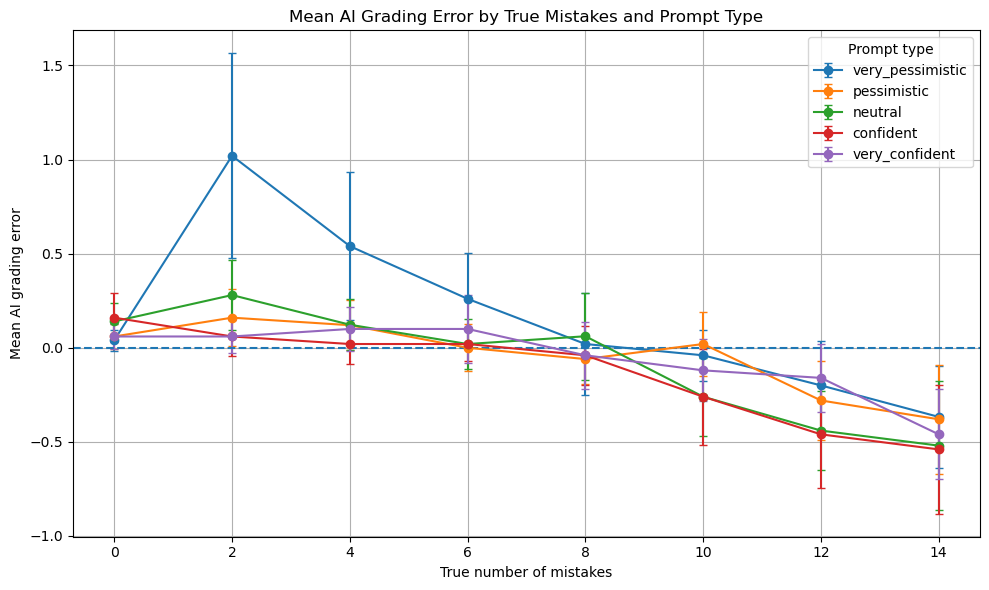

In [29]:
df_art = aligned_rank_transform(
    df=df,
    dv="ai_error",
    within="prompt_type",
    between="true_mistakes",
    subject="answer_key_id"
)

#Trin 5: Kør Mixed ANOVA på Y'' for hver effekt
res_A = pg.mixed_anova(
    data=df_art, dv="Y_ranked_A",
    within="prompt_type", between="true_mistakes",
    subject="answer_key_id"
)
pg.print_table(res_A[res_A["Source"] == "prompt_type"])

res_B = pg.mixed_anova(
    data=df_art, dv="Y_ranked_B",
    within="prompt_type", between="true_mistakes",
    subject="answer_key_id"
)
pg.print_table(res_B[res_B["Source"] == "true_mistakes"])


res_AB = pg.mixed_anova(
    data=df_art, dv="Y_ranked_AB",
    within="prompt_type", between="true_mistakes",
    subject="answer_key_id"
)
pg.print_table(res_AB[res_AB["Source"] == "Interaction"])


#GRAF

summary = (
    df.groupby(["true_mistakes", "prompt_type"], observed=False)
    .agg(
        mean_ai_error=("ai_error", "mean"),
        sd_ai_error=("ai_error", "std"),
        n=("ai_error", "count")
    )
    .reset_index()
)

summary["se_ai_error"] = summary["sd_ai_error"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["se_ai_error"]
summary["true_mistakes_numeric"] = summary["true_mistakes"].astype(int)

plt.figure(figsize=(10, 6))

for prompt in summary["prompt_type"].unique():
    subset = summary[summary["prompt_type"] == prompt]

    plt.errorbar(
        subset["true_mistakes_numeric"],
        subset["mean_ai_error"],
        yerr=subset["ci95"],
        marker="o",
        capsize=3,
        label=str(prompt)
    )
plt.axhline(0, linestyle="--")
plt.title("Mean AI Grading Error by True Mistakes and Prompt Type")
plt.xlabel("True number of mistakes")
plt.ylabel("Mean AI grading error")
plt.legend(title="Prompt type")
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
# Post-hoc tests between prompts
# Since prompt_type is a repeated-measures factor, comparisons between prompts should be paired t-tests with holm-correction.

posthoc_sign_prompts = pg.pairwise_tests(
    data=df_art,
    dv="ai_error",
    within="prompt_type",
    subject="answer_key_id",
    parametric=True,
    padjust="holm",
    effsize="hedges"
)

print(posthoc_sign_prompts)

posthoc_sign_true_mistakes = pg.pairwise_tests(
    data=df_art,
    dv="ai_error",
    between="true_mistakes",
    subject="answer_key_id",
    parametric=True,
    padjust="holm",
    effsize="hedges"
)
print(posthoc_sign_true_mistakes)


      Contrast               A                 B  Paired  Parametric  \
0  prompt_type       confident           neutral    True        True   
1  prompt_type       confident       pessimistic    True        True   
2  prompt_type       confident    very_confident    True        True   
3  prompt_type       confident  very_pessimistic    True        True   
4  prompt_type         neutral       pessimistic    True        True   
5  prompt_type         neutral    very_confident    True        True   
6  prompt_type         neutral  very_pessimistic    True        True   
7  prompt_type     pessimistic    very_confident    True        True   
8  prompt_type     pessimistic  very_pessimistic    True        True   
9  prompt_type  very_confident  very_pessimistic    True        True   

          T    dof alternative     p_unc    p_corr p_adjust      BF10  \
0 -1.284328  302.0   two-sided  0.200011  0.800046     holm     0.145   
1 -2.213161  302.0   two-sided  0.027634  0.165804     holm  

In [31]:
# Bonferroni-korrektion for 10 sammenligninger
alpha_corrected = 0.05 / 10

results = posthoc_sign_prompts.copy()
# Cohen's dz fra paired t-test
results["dz"] = (
    results["T"].abs()
    / np.sqrt(results["dof"] + 1)
)

# Beregn nødvendigt antal par / answer sheets
results["required_n"] = results["dz"].apply(
    lambda dz: np.ceil(
        pg.power_ttest(
            d=dz,
            n=None,
            power=0.80,
            alpha=alpha_corrected,
            contrast="paired",
            alternative="two-sided"
            ))).astype(int)

display(results[["A", "B", "T", "dz", "required_n"]])

alpha_corrected2=0.05/28
results2=posthoc_sign_true_mistakes.copy()

results2["dz"] = (
    results2["T"].abs()
    / np.sqrt(results2["dof"] + 1)
)

# Beregn nødvendigt antal par / answer sheets
results2["required_n"] = results2["dz"].apply(
    lambda dz: np.ceil(
        pg.power_ttest(
            d=dz,
            n=None,
            power=0.80,
            alpha=alpha_corrected2,
            contrast="two-samples",
            alternative="two-sided"
            ))).astype(int)

display(results2[["A", "B", "T", "dz", "required_n"]])


print(
    "Maximum required answer sheets:",
    results["required_n"].max()
)

print(
    "Maximum required answer sheets:",
    results2["required_n"].max()
)

,A,B,T,dz,required_n
0,confident,neutral,-1.284328,0.073783,2450
1,confident,pessimistic,-2.213161,0.127143,828
2,confident,very_confident,-2.171984,0.124777,859
3,confident,very_pessimistic,-4.683162,0.269041,188
4,neutral,pessimistic,-0.972894,0.055891,4266
5,neutral,very_confident,-0.939574,0.053977,4574
6,neutral,very_pessimistic,-3.863791,0.221969,275
7,pessimistic,very_confident,0.067681,0.003888,880586
8,pessimistic,very_pessimistic,-3.261527,0.187370,384
9,very_confident,very_pessimistic,-3.334323,0.191552,367


,A,B,T,dz,required_n
0,0,10,4.632809,0.207393,734
1,0,12,7.162108,0.320620,309
2,0,14,7.698528,0.450875,158
3,0,2,-3.254360,0.145685,1485
4,0,4,-1.693204,0.093043,3636
5,0,6,0.283814,0.012705,194819
6,0,8,2.099619,0.113539,2442
7,10,12,2.578916,0.115448,2362
8,10,14,3.971838,0.192435,852
9,10,2,-5.655059,0.253155,494


Maximum required answer sheets: 880586
Maximum required answer sheets: 194819


Og så for absolut error

Verificering — aligned kolonner skal summe til ~0:
  Y'_A  sum: -0.000000
  Y'_B  sum: -0.000000
  Y'_AB sum: 0.000000

ANOVA SUMMARY

Source                  SS    DF1    DF2            MS         F    p_unc    p_GG_corr    np2    eps  sphericity      W_spher    p_spher
-----------  -------------  -----  -----  ------------  --------  -------  -----------  -----  -----  ------------  ---------  ---------
prompt_type  292133392.119      4   1180  73033348.030  9679.643    0.000        0.000  0.970  0.513  False             0.084      0.000


ANOVA SUMMARY

Source                    SS    DF1    DF2            MS         F    p_unc    p_GG_corr    np2    eps    sphericity    W_spher    p_spher
-------------  -------------  -----  -----  ------------  --------  -------  -----------  -----  -----  ------------  ---------  ---------
true_mistakes  260176116.081      7    295  37168016.583  1186.118    0.000          nan  0.966    nan           nan        nan        nan


ANOVA SUMMARY

Sou

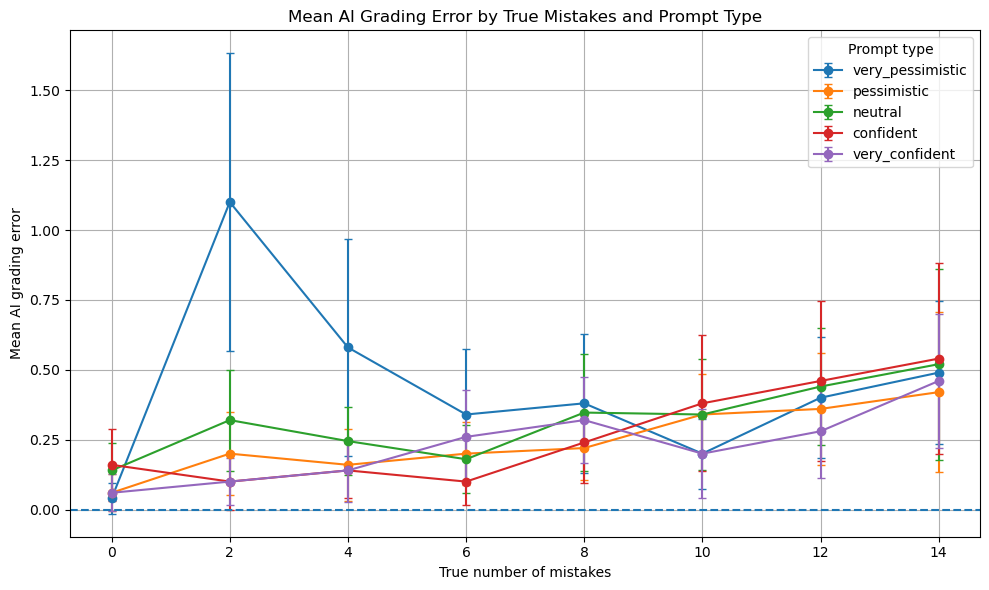

In [32]:
df_art = aligned_rank_transform(
    df=df,
    dv="Absolute_error",
    within="prompt_type",
    between="true_mistakes",
    subject="answer_key_id"
)

#Trin 5: Kør Mixed ANOVA på Y'' for hver effekt
res_A = pg.mixed_anova(
    data=df_art, dv="Y_ranked_A",
    within="prompt_type", between="true_mistakes",
    subject="answer_key_id"
)
pg.print_table(res_A[res_A["Source"] == "prompt_type"])

res_B = pg.mixed_anova(
    data=df_art, dv="Y_ranked_B",
    within="prompt_type", between="true_mistakes",
    subject="answer_key_id"
)
pg.print_table(res_B[res_B["Source"] == "true_mistakes"])


res_AB = pg.mixed_anova(
    data=df_art, dv="Y_ranked_AB",
    within="prompt_type", between="true_mistakes",
    subject="answer_key_id"
)
pg.print_table(res_AB[res_AB["Source"] == "Interaction"])


#GRAF

summary = (
    df.groupby(["true_mistakes", "prompt_type"], observed=False)
    .agg(
        mean_ai_error=("Absolute_error", "mean"),
        sd_ai_error=("Absolute_error", "std"),
        n=("Absolute_error", "count")
    )
    .reset_index()
)

summary["se_ai_error"] = summary["sd_ai_error"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["se_ai_error"]
summary["true_mistakes_numeric"] = summary["true_mistakes"].astype(int)

plt.figure(figsize=(10, 6))

for prompt in summary["prompt_type"].unique():
    subset = summary[summary["prompt_type"] == prompt]

    plt.errorbar(
        subset["true_mistakes_numeric"],
        subset["mean_ai_error"],
        yerr=subset["ci95"],
        marker="o",
        capsize=3,
        label=str(prompt)
    )

plt.axhline(0, linestyle="--")
plt.title("Mean AI Grading Error by True Mistakes and Prompt Type")
plt.xlabel("True number of mistakes")
plt.ylabel("Mean AI grading error")
plt.legend(title="Prompt type")
plt.grid(True)
plt.tight_layout()
plt.show()


In [33]:
# Post-hoc tests between prompts
# Since prompt_type is a repeated-measures factor, comparisons between prompts should be paired t-tests with holm-correction.

posthoc_abs_prompts = pg.pairwise_tests(
    data=df_art,
    dv="Absolute_error",
    within="prompt_type",
    subject="answer_key_id",
    parametric=True,
    padjust="holm",
    effsize="hedges"
)

print(posthoc_abs_prompts)

posthoc_abs_true_mistakes = pg.pairwise_tests(
    data=df_art,
    dv="Absolute_error",
    between="true_mistakes",
    subject="answer_key_id",
    parametric=True,
    padjust="holm",
    effsize="hedges"
)
print(posthoc_abs_true_mistakes)


      Contrast               A                 B  Paired  Parametric  \
0  prompt_type       confident           neutral    True        True   
1  prompt_type       confident       pessimistic    True        True   
2  prompt_type       confident    very_confident    True        True   
3  prompt_type       confident  very_pessimistic    True        True   
4  prompt_type         neutral       pessimistic    True        True   
5  prompt_type         neutral    very_confident    True        True   
6  prompt_type         neutral  very_pessimistic    True        True   
7  prompt_type     pessimistic    very_confident    True        True   
8  prompt_type     pessimistic  very_pessimistic    True        True   
9  prompt_type  very_confident  very_pessimistic    True        True   

          T    dof alternative     p_unc    p_corr p_adjust    BF10    hedges  
0 -1.376672  302.0   two-sided  0.169633  0.678533     holm   0.164 -0.102292  
1  0.086485  302.0   two-sided  0.931138  1.000

         Contrast   A   B  Paired  Parametric         T         dof  \
0   true_mistakes   0  10   False        True -4.400816  498.000000   
1   true_mistakes   0  12   False        True -5.500804  498.000000   
2   true_mistakes   0  14   False        True -5.624972  291.675742   
3   true_mistakes   0   2   False        True -4.007553  498.000000   
4   true_mistakes   0   4   False        True -3.146069  334.566593   
5   true_mistakes   0   6   False        True -3.075093  498.000000   
6   true_mistakes   0   8   False        True -4.575549  359.134827   
7   true_mistakes  10  12   False        True -1.488164  498.000000   
8   true_mistakes  10  14   False        True -2.468922  409.524186   
9   true_mistakes  10   2   False        True -0.939556  498.000000   
10  true_mistakes  10   4   False        True  0.625500  486.822802   
11  true_mistakes  10   6   False        True  1.413263  498.000000   
12  true_mistakes  10   8   False        True -0.158883  496.955007   
13  tr

Nu til sample size test for endelig forsøg

In [34]:
# Bonferroni-korrektion for 10 sammenligninger
alpha_corrected = 0.05 / 10

results = posthoc_abs_prompts.copy()
# Cohen's dz fra paired t-test
results["dz"] = (
    results["T"].abs()
    / np.sqrt(results["dof"] + 1)
)

# Beregn nødvendigt antal par / answer sheets
results["required_n"] = results["dz"].apply(
    lambda dz: np.ceil(
        pg.power_ttest(
            d=dz,
            n=None,
            power=0.80,
            alpha=alpha_corrected,
            contrast="paired",
            alternative="two-sided"
            ))).astype(int)

display(results[["A", "B", "T", "dz", "required_n"]])

alpha_corrected2=0.05/28
results2=posthoc_abs_true_mistakes.copy()

results2["dz"] = (
    results2["T"].abs()
    / np.sqrt(results2["dof"] + 1)
)

# Beregn nødvendigt antal par / answer sheets
results2["required_n"] = results2["dz"].apply(
    lambda dz: np.ceil(
        pg.power_ttest(
            d=dz,
            n=None,
            power=0.80,
            alpha=alpha_corrected2,
            contrast="two-samples",
            alternative="two-sided"
            ))).astype(int)

display(results2[["A", "B", "T", "dz", "required_n"]])


print(
    "Maximum required answer sheets:",
    results["required_n"].max()
)

print(
    "Maximum required answer sheets:",
    results2["required_n"].max()
)

,A,B,T,dz,required_n
0,confident,neutral,-1.376672,0.079088,2133
1,confident,pessimistic,0.086485,0.004968,539298
2,confident,very_confident,0.611595,0.035135,10788
3,confident,very_pessimistic,-2.937414,0.168750,472
4,neutral,pessimistic,1.537023,0.088300,1712
5,neutral,very_confident,2.114489,0.121474,907
6,neutral,very_pessimistic,-2.217577,0.127396,825
7,pessimistic,very_confident,0.612132,0.035166,10770
8,pessimistic,very_pessimistic,-3.234796,0.185834,390
9,very_confident,very_pessimistic,-3.600325,0.206833,316


,A,B,T,dz,required_n
0,0,10,-4.400816,0.197008,813
1,0,12,-5.500804,0.246250,522
2,0,14,-5.624972,0.328796,294
3,0,2,-4.007553,0.179403,980
4,0,4,-3.146069,0.171743,1069
5,0,6,-3.075093,0.137660,1662
6,0,8,-4.575549,0.241107,544
7,10,12,-1.488164,0.066619,7089
8,10,14,-2.468922,0.121853,2121
9,10,2,-0.939556,0.042060,17780


Maximum required answer sheets: 539298
Maximum required answer sheets: 620339


ANOVA´s tommelfinger regel ligger på n=30 minimum sample size, vi tester derfor ikke dette da post-hoc har vist at kræve meget mere. 

In [35]:
import pandas as pd
from statsmodels.stats.contingency_tables import cochrans_q

# Load data
df = pd.read_csv("Output_extraction/ai_grading_final.csv")

# Clean columns
df["answer_key_id"] = df["answer_key_id"].astype(str).str.strip()
df["prompt_type"] = df["prompt_type"].astype(str).str.strip()

# Check prompt names
print(df["prompt_type"].unique())

# Binary outcome: exact correct estimate or not
df["correct_estimate"] = (
    df["ai_estimated_mistakes"] == df["true_mistakes"]
).astype(int)

# Create repetition number because answer_key_id is not always unique
df["rep"] = df.groupby(
    ["answer_key_id", "true_mistakes", "prompt_type"]
).cumcount()

# Convert to wide format
df_wide = df.pivot_table(
    index=["answer_key_id", "true_mistakes", "rep"],
    columns="prompt_type",
    values="correct_estimate",
    aggfunc="first"
)

print(df_wide.columns.tolist())

# Prompt order
prompt_order = [
    "very_pessimistic",
    "pessimistic",
    "neutral",
    "confident",
    "very_confident"
]

# Keep only rows where all five prompt types are present
df_wide = df_wide[prompt_order].dropna()

# Cochran's Q-test
result = cochrans_q(df_wide)

print(result)

<StringArray>
['very_pessimistic', 'pessimistic', 'neutral', 'confident', 'very_confident']
Length: 5, dtype: str
['confident', 'neutral', 'pessimistic', 'very_confident', 'very_pessimistic']
df          4
pvalue      0.17631817162635052
statistic   6.32258064516129


In [36]:
from statsmodels.stats.contingency_tables import mcnemar
from itertools import combinations
from statsmodels.stats.multitest import multipletests

posthoc_results = []

for p1, p2 in combinations(prompt_order, 2):
    table = pd.crosstab(df_wide[p1], df_wide[p2])

    # Make sure table is 2x2
    table = table.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

    test = mcnemar(table, exact=True)

    posthoc_results.append({
        "comparison": f"{p1} vs {p2}",
        "p_value": test.pvalue
    })

posthoc_df = pd.DataFrame(posthoc_results)

# Holm correction
posthoc_df["p_holm"] = multipletests(
    posthoc_df["p_value"],
    method="holm"
)[1]

print(posthoc_df)

                           comparison   p_value    p_holm
0     very_pessimistic vs pessimistic  0.433537  1.000000
1         very_pessimistic vs neutral  0.792583  1.000000
2       very_pessimistic vs confident  0.097812  0.880310
3  very_pessimistic vs very_confident  0.254125  1.000000
4              pessimistic vs neutral  0.254125  1.000000
5            pessimistic vs confident  0.411423  1.000000
6       pessimistic vs very_confident  0.778876  1.000000
7                neutral vs confident  0.033788  0.337882
8           neutral vs very_confident  0.117213  0.937704
9         confident vs very_confident  0.642667  1.000000


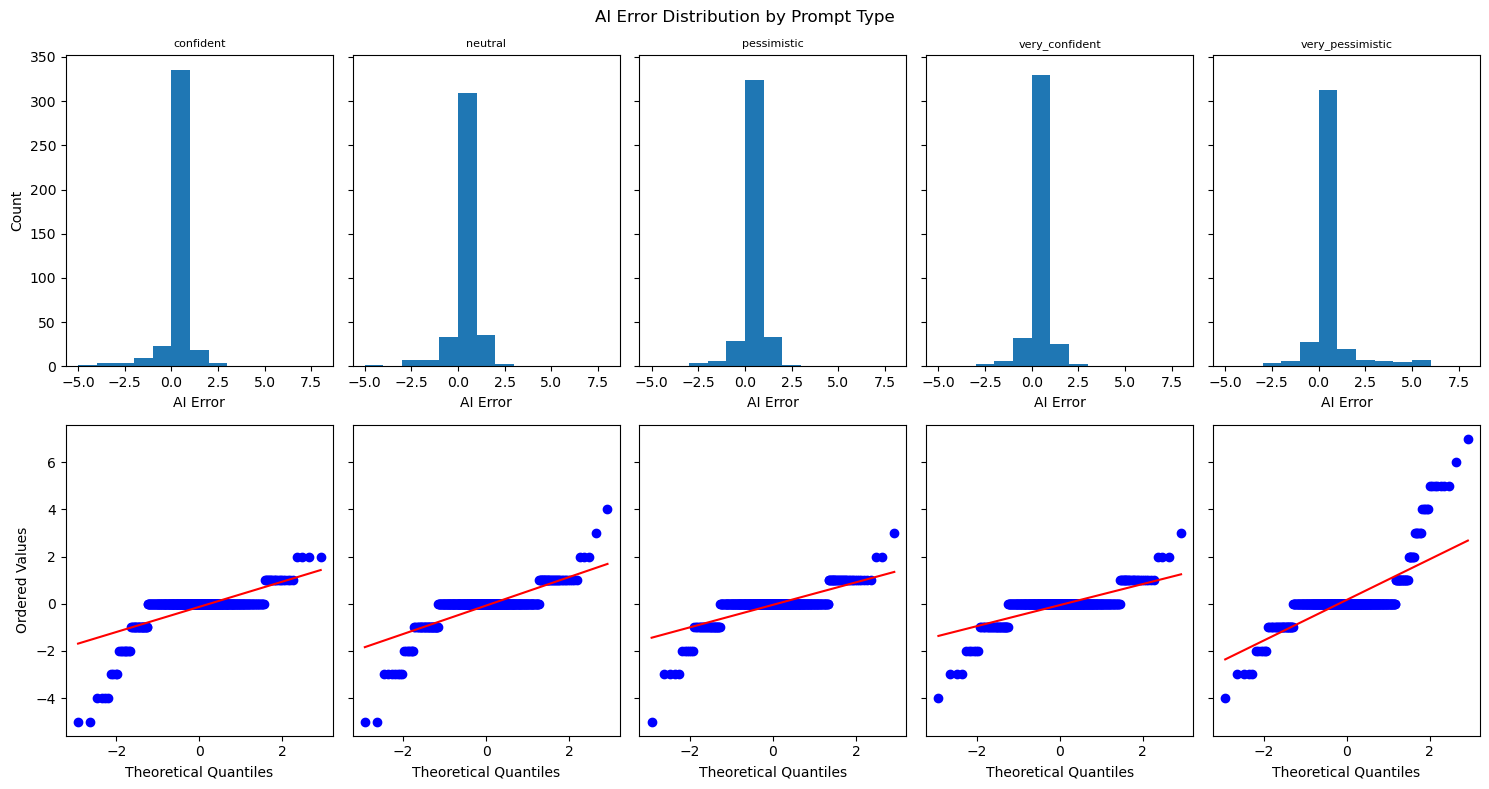

In [54]:
error_by_prompt = df.groupby("prompt_type", observed=True)["ai_error"].apply(list)

prompt_types = error_by_prompt.index.tolist()

all_data = [x for sublist in error_by_prompt.values for x in sublist]
global_bins = np.arange(min(all_data), max(all_data) + 2)

fig, axes = plt.subplots(2, len(prompt_types), figsize=(15, 8), sharey="row")

for j, prompt_type in enumerate(prompt_types):
    # Row 1: histograms
    ax = axes[0, j]
    ax.hist(error_by_prompt[prompt_type], bins=global_bins)
    ax.set_title(prompt_type, fontsize=8)
    if j == 0:
        ax.set_ylabel("Count")
    ax.set_xlabel("AI Error")

    # Row 2: QQ plots
    ax = axes[1, j]
    from scipy import stats
    stats.probplot(error_by_prompt[prompt_type], dist="norm", plot=ax)
    ax.set_title("")  # remove redundant title
    if j != 0:
        ax.set_ylabel("")
    ax.set_xlabel("Theoretical Quantiles")

plt.suptitle("AI Error Distribution by Prompt Type")
plt.tight_layout()
plt.show()

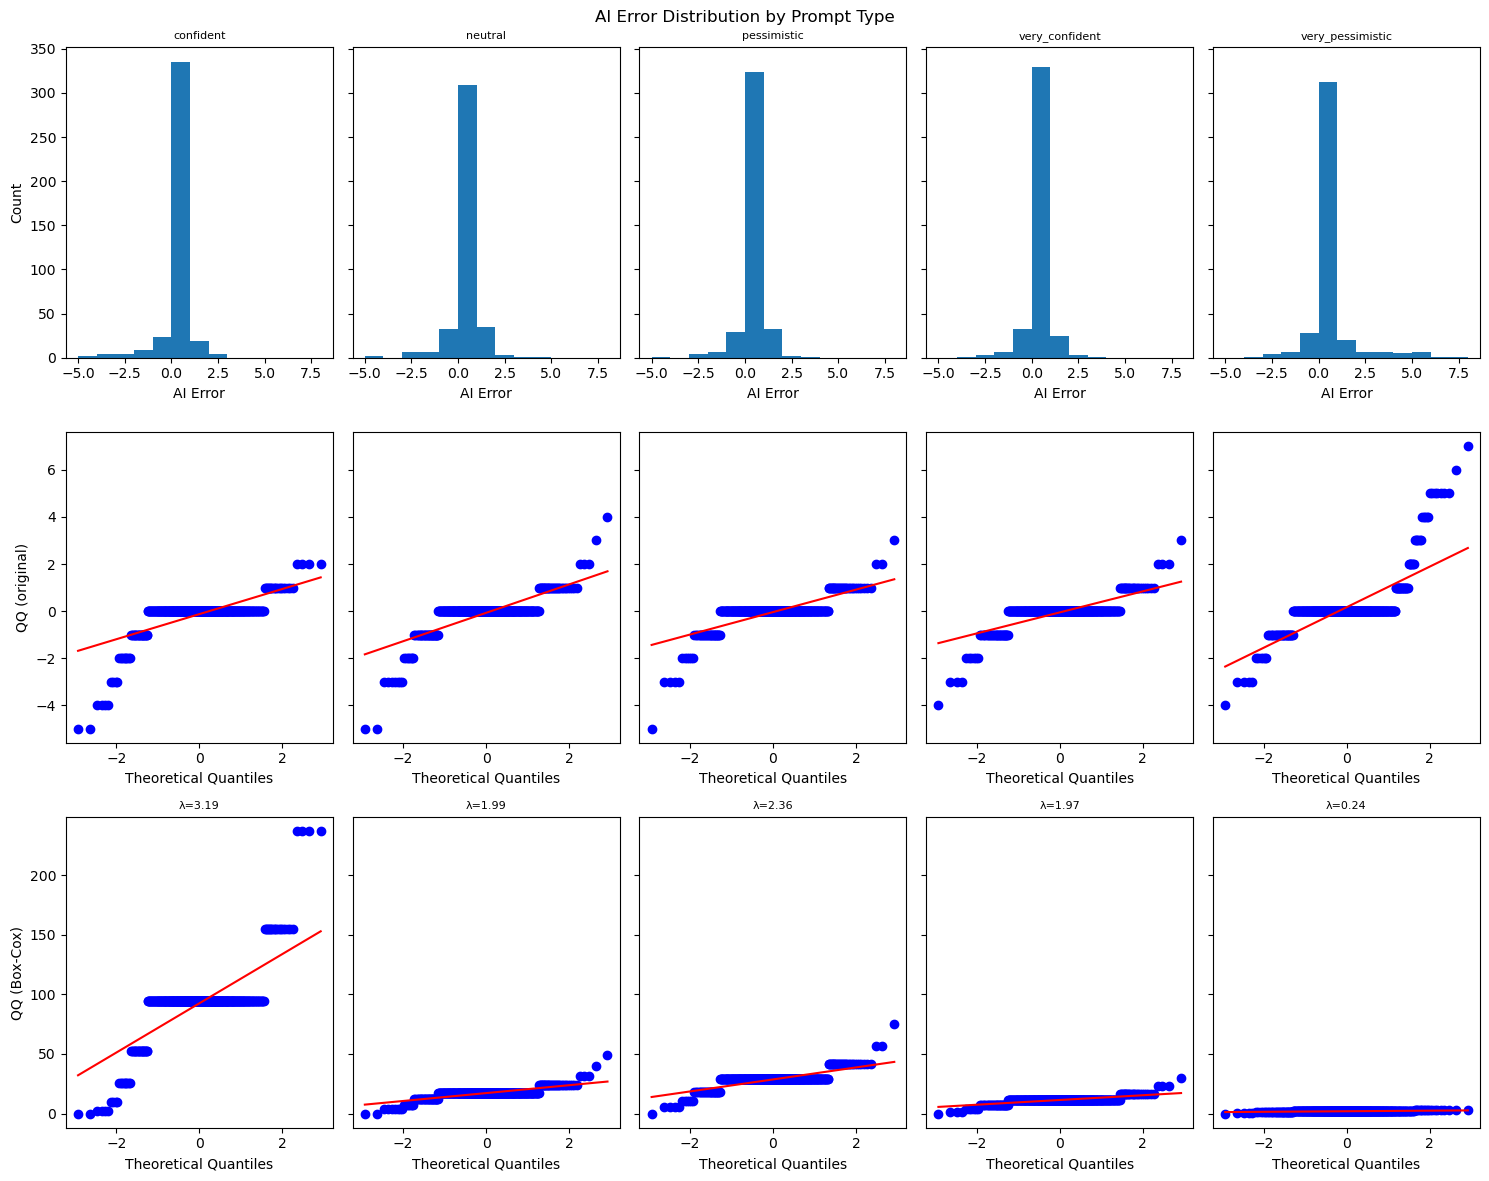

In [55]:
error_by_prompt = df.groupby("prompt_type", observed=True)["ai_error"].apply(list)
prompt_types = error_by_prompt.index.tolist()

all_data = [x for sublist in error_by_prompt.values for x in sublist]
global_bins = np.arange(min(all_data), max(all_data) + 2)

fig, axes = plt.subplots(3, len(prompt_types), figsize=(15, 12), sharey="row")

for j, prompt_type in enumerate(prompt_types):
    data = np.array(error_by_prompt[prompt_type])

    # Box-Cox requires strictly positive values
    shift = abs(data.min()) + 1
    data_shifted = data + shift
    data_boxcox, lambda_ = boxcox(data_shifted)

    # Row 1: histograms
    ax = axes[0, j]
    ax.hist(data, bins=global_bins)
    ax.set_title(prompt_type, fontsize=8)
    if j == 0:
        ax.set_ylabel("Count")
    ax.set_xlabel("AI Error")

    # Row 2: QQ plots (original)
    ax = axes[1, j]
    stats.probplot(data, dist="norm", plot=ax)
    ax.set_title("")
    if j != 0:
        ax.set_ylabel("")
    ax.set_xlabel("Theoretical Quantiles")

    # Row 3: QQ plots (box-cox transformed)
    ax = axes[2, j]
    stats.probplot(data_boxcox, dist="norm", plot=ax)
    ax.set_title(f"λ={lambda_:.2f}", fontsize=8)
    if j != 0:
        ax.set_ylabel("")
    ax.set_xlabel("Theoretical Quantiles")

axes[1, 0].set_ylabel("QQ (original)")
axes[2, 0].set_ylabel("QQ (Box-Cox)")

plt.suptitle("AI Error Distribution by Prompt Type")
plt.tight_layout()
plt.show()